# ESM C Implementation (62% Train Spearman R, 43% Validation Spearman R)

Within each cycle of active learning:

1. Collect training data (original training data + your query data).

2. Train a prediction model to predict the DMS_score for each mutant (e.g., M0A).

3. Use the trained model to predict the score for all mutant in the test set.

4. Select query mutants for next round based on certain criteria. You may want to make sure you don't query the same mutant twice as you only have limited chances to make queries.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
import random
from copy import deepcopy
import pandas as pd
from scipy.stats import spearmanr
import argparse
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression

import os
from tqdm.auto import tqdm

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

## 1. Collect Training Data

In [2]:
#with open('Hackathon_data/Hackathon_data/sequence.fasta', 'r') as f:
with open('sequence.fasta', 'r') as f:
  data = f.readlines()

sequence_wt = data[1].strip()
sequence_wt

'MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLREKMRRRLESGDKWFSLEFFPPRTAEGAVNLISRFDRMAAGGPLYIDVTWHPAGDPGSDKETSSMMIASTAVNYCGLETILHMTCCRQRLEEITGHLHKAKQLGLKNIMALRGDPIGDQWEEEEGGFNYAVDLVKHIRSEFGDYFDICVAGYPKGHPEAGSFEADLKHLKEKVSAGADFIITQLFFEADTFFRFVKACTDMGITCPIVPGIFPIQGYHSLRQLVKLSKLEVPQEIKDVIEPIKDNDAAIRNYGIELAVSLCQELLASGLVPGLHFYTLNREMATTEVLKRLGMWTEDPRRPLPWALSAHPKRREEDVRPIFWASRPKSYIYRTQEWDEFPNGRWGNSSSPAFGELKDYYLFYLKSKSPKEELLKMWGEELTSEESVFEVFVLYLSGEPNRNGHKVTCLPWNDEPLAAETSLLKEELLRVNRQGILTINSQPNINGKPSSDPIVGWGPSGGYVFQKAYLEFFTSRETAEALLQVLKKYELRVNYHLVNVKGENITNAPELQPNAVTWGIFPGREIIQPTVVDPVSFMFWKDEAFALWIERWGKLYEEESPSRTIIQYIHDNYFLVNLVDNDFPLDNCLWQVVEDTLELLNRPTQNARETEAP'

In [3]:
len(sequence_wt)

656

In [4]:
def get_mutated_sequence(mut, sequence_wt):
    '''
    Adds the specified mutation into the wild-type sequence.

    Params:
        mut (str): The mutation to be applied.
        sequence_wt (str): The wild-type sequence to which the mutation will be applied.
    Returns:
        A deep copy of the mutated sequence string.
    '''
    # wt - wild type; pos - position; mt - mutation
    wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]

    sequence = deepcopy(sequence_wt)

    return sequence[:pos] + mt + sequence[pos+1:]

In [5]:
#df_train = pd.read_csv('Hackathon_data/Hackathon_data/train.csv')
df_train = pd.read_csv('train.csv')
df_train['sequence'] = df_train.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_train

,mutant,DMS_score,sequence
0,M0Y,0.2730,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.2857,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.2153,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.3122,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.2180,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1135,P347D,0.3876,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1136,P347C,0.1837,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1137,P347A,0.4611,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1138,P347M,0.2412,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [6]:
#df_test = pd.read_csv('Hackathon_data/Hackathon_data/test.csv')
df_test = pd.read_csv('test.csv')
df_test['sequence'] = df_test.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test

,mutant,sequence
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [7]:
# TODO: integrate the query data that you acquired each round into df_train

## 2. Train a Prediction Model

### Hyperparameters

In [8]:
seq_length = 656
seed = 0 # seed for splitting the validation set
val_ratio = 0.2 # proportion of validation set

### ProteinDataset
Convert amino acids to machine-readable data via embedding space.

In [9]:
def gen_emb_from_df(df, out_dir="esm_c_embeddings_variants", device="cuda:0", batch_size=8):
    '''
    Generate and cache ESM-C sequence embeddings for each unique mutant.
    Saves one mean-pooled embedding tensor per mutant to out_dir/{mutant}.pt.
    '''
    os.makedirs(out_dir, exist_ok=True)

    if isinstance(device, torch.device):
        use_cuda = device.type == "cuda"
    else:
        use_cuda = str(device).startswith("cuda")
    device = torch.device(device) if not isinstance(device, torch.device) else device

    # Each item is (name_for_file, sequence)
    data = [(m, s[:1000]) for m, s in df[["mutant", "sequence"]].drop_duplicates().values]
    print(f"Number of unique variants: {len(data)}")

    # Instantiate 600-million-parameter ESM-C model
    model = ESMC.from_pretrained("esmc_600m").to(device).eval()
    if use_cuda:
        model.half()  # Half-prec. to reduce GPU memory and runtime

    for i in tqdm(range(int(np.ceil(len(data) / batch_size)))):
        batch = data[i * batch_size:(i + 1) * batch_size]

        # Cache skip
        if all(os.path.exists(os.path.join(out_dir, f"{name}.pt")) for name, _ in batch):
            continue

        for name, sequence in batch:
            path = os.path.join(out_dir, f"{name}.pt")
            if os.path.exists(path):
                continue

            protein = ESMProtein(sequence=sequence)

            with torch.no_grad():
                protein_tensor = model.encode(protein)
                model_output = model.logits(
                    protein_tensor,
                    LogitsConfig(sequence=True, return_embeddings=True),
                )

            seq_emb = model_output.embeddings

            # Handle both [L, D] and [1, L, D] output shapes.
            if seq_emb.ndim == 3:
                seq_emb = seq_emb[0]
            seq_mean = seq_emb.float().mean(dim=0).detach().cpu()

            torch.save(seq_mean, path)

class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, is_train=True):
        self.df = df.reset_index(drop=True)
        self.emb_dir = emb_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        mutant = self.df.loc[idx, "mutant"]
        emb = torch.load(os.path.join(self.emb_dir, f"{mutant}.pt")).float()
        if self.is_train:
            y = torch.tensor(self.df.loc[idx, "DMS_score"], dtype=torch.float32)
            return emb, y
        return emb, torch.tensor(0.0, dtype=torch.float32)

In [10]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA device found; using CPU.")

# Run on GPU 0 when available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

True
NVIDIA GeForce RTX 5070 Laptop GPU


In [11]:
# Combine our datasets for embedding, them split them into train / test sets afterward. Each has mutated sequence variants stored as a separate .pt embedding.
all_df = pd.concat(
    [df_train[["mutant", "sequence"]], df_test[["mutant", "sequence"]]],
    ignore_index=True
).drop_duplicates("mutant")

gen_emb_from_df(all_df, out_dir="esm_c_embeddings_variants", device=device, batch_size=8)

Number of unique variants: 12464


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1558 [00:00<?, ?it/s]

In [12]:
# gen_emb('Hackathon_Data/Hackathon_data/sequence.fasta', out_dir='esm_embeddings_train')
# gen_emb('Hackathon_Data/Hackathon_data/', out_dir='esm_embeddings_test')

In [ ]:
# Use simple MLP model to predict from ESM C embeddings.
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout_p=0.3, num_layers=7):
        super().__init__()

        num_layers = max(1, int(num_layers))
        hidden_dim = int(hidden_dim)

        layers = []
        prev_dim = input_dim
        curr_dim = hidden_dim

        for layer_idx in range(num_layers):
            # Keep layer widths consistent by explicitly tracking in/out dims.
            if layer_idx == 0:
                next_dim = curr_dim
            elif ((num_layers-1) % 2 == 0) and (layer_idx == (num_layers-1) / 2):   # If an odd dimension, keep dimension constant for middle layer.
                next_dim = curr_dim
            elif layer_idx < num_layers / 2:
                next_dim = curr_dim * 2
            else:
                next_dim = curr_dim // 2

            layers.extend([
                nn.Linear(prev_dim, next_dim),
                nn.BatchNorm1d(next_dim),
                nn.ReLU(),
                nn.Dropout(dropout_p),
            ])

            prev_dim = next_dim
            curr_dim = next_dim

        self.layers = nn.Sequential(
            *layers,
            nn.Linear(prev_dim, 1),
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

In [14]:
'''
Params:
    model (torch.nn):               The untrained Fully-Connected Neural Network (FCN)
    train_dataset (DmsESMDataset):  The training dataset
    val_dataset (DmsESMDataset):    The validation dataset
    epochs (int):                   The number of epochs over which to train
    batch_size (int):               The number of batches in which to split the input data
    lr (float):                     The learning rate
    patience (int):                 The number of epochs to wait while the validation metric shows no improvement
    alpha (float):                  The Exponential Moving Average (EMA) weight by which the Spearman R is smoothed
    device (str):                   The CPU / GPU on which to run the model
Returns:
    model (torch.nn):               The trained FCN
    best_ckpt (dictionary):         Dictionary saving the best parameters
    train_losses (list):            Per-epoch training losses
    val_losses (list):              Per-epoch validation losses
'''
def train_model_esm(model, train_dataset, val_dataset, epochs=100, batch_size=256, lr=1e-3, patience=20, alpha=0.3, weight_decay=1e-4, clip_thresh=1.0, scheduler_rate=0.5, device='cuda:0'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Use MSE loss to handle bounded regression.
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=scheduler_rate, patience=5)
    

    best_val_spearman = -np.inf
    best_ckpt = None
    patience_counter = 0
    val_spearman_ema = None

    # History lists for plotting (one scalar per epoch).
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        # Per-epoch collectors.
        epoch_train_losses = []
        epoch_train_preds = []
        epoch_train_targets = []

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_thresh, norm_type=2.0)
            optimizer.step()

            epoch_train_losses.append(loss.item())
            epoch_train_preds.append(outputs.detach().cpu())
            epoch_train_targets.append(targets.detach().cpu())

        train_preds_np = torch.cat(epoch_train_preds).numpy()
        train_targets_np = torch.cat(epoch_train_targets).numpy()
        train_spearman = spearmanr(train_preds_np, train_targets_np).statistic

        # Validation
        model.eval()
        epoch_val_losses = []
        epoch_val_preds = []
        epoch_val_targets = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device).float()
                outputs = model(inputs).squeeze(-1)

                epoch_val_losses.append(criterion(outputs, targets).item())
                epoch_val_preds.append(outputs.detach().cpu())
                epoch_val_targets.append(targets.detach().cpu())

        val_preds_np = torch.cat(epoch_val_preds).numpy()
        val_targets_np = torch.cat(epoch_val_targets).numpy()
        val_spearman = spearmanr(val_preds_np, val_targets_np).statistic
        mean_train_loss = float(np.mean(epoch_train_losses))
        mean_val_loss = float(np.mean(epoch_val_losses))

        # Save per-epoch losses for plotting.
        train_losses.append(mean_train_loss)
        val_losses.append(mean_val_loss)

        if np.isnan(train_spearman):
            train_spearman = 0.0
        if np.isnan(val_spearman):
            val_spearman = -1.0

        # Initialize EMA on first epoch, then update.
        if val_spearman_ema is None:
            val_spearman_ema = val_spearman
        else:
            val_spearman_ema = alpha * val_spearman + (1 - alpha) * val_spearman_ema

        scheduler.step(val_spearman_ema)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={mean_train_loss:.4f}, Train Spearman={train_spearman:.4f}, "
            f"Val Loss={mean_val_loss:.4f}, Val Spearman={val_spearman:.4f}, "
            f"LR={optimizer.param_groups[0]['lr']:.6g}"
        )

        # Early stopping on validation Spearman (ranking quality)
        if val_spearman_ema > best_val_spearman:
            best_val_spearman = val_spearman_ema
            best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_ckpt is None:
        best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return model, best_ckpt, train_losses, val_losses

In [15]:
# Build only the test dataset/loader here; train/val splits are created per CV fold.
n_splits = 3    # 5
test_ds = DmsESMDataset(df_test, "esm_c_embeddings_variants", is_train=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [16]:
import optuna

# Helper function for plotting
def mean_curve(curves, max_len):
        arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
        for i, curve in enumerate(curves):
            arr[i, :len(curve)] = curve
        return np.nanmean(arr, axis=0).tolist()

In [17]:
# --------------- Train our model with cross-validation + Optuna ---------------
kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
indices = np.arange(len(df_train))

train_losses = []
val_losses = []

# Define Optuna objective over CV folds.
def objective(trial):
    fold_train_losses = []
    fold_val_losses = []
    fold_val_spearmans = []

    hidden_dim = trial.suggest_int("hidden_dim", 64, 1280, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.05, 0.5)
    num_layers = trial.suggest_int("num_layers", 2, 8)

    batch_size = trial.suggest_int("batch_size", 64, 256, step=32)
    lr = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    patience = trial.suggest_int("patience", 5, 40, step=5)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    clip_thresh = trial.suggest_float("clip_thresh", 0.0, 5.0, step=0.5)
    scheduler_rate = trial.suggest_float("scheduler_rate", 0.3, 0.7)

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"\n========== Fold {fold}/{n_splits} ==========")

        df_train_split = df_train.iloc[train_idx].reset_index(drop=True)
        df_val_split = df_train.iloc[val_idx].reset_index(drop=True)

        train_ds = DmsESMDataset(df_train_split, "esm_c_embeddings_variants", is_train=True)
        val_ds = DmsESMDataset(df_val_split, "esm_c_embeddings_variants", is_train=True)

        model_fold = MLPRegressor(
            input_dim=1152,
            hidden_dim=hidden_dim,
            dropout_p=dropout_p,
            num_layers=num_layers,
        ).to(device)

        model_fold, best_ckpt_fold, train_losses_fold, val_losses_fold = train_model_esm(
            model_fold,
            train_ds,
            val_ds,
            epochs=3,
            batch_size=batch_size,
            lr=lr,
            patience=patience,
            weight_decay=weight_decay,
            clip_thresh=clip_thresh,
            scheduler_rate=scheduler_rate,
            device=device,
        )
        model_fold.load_state_dict(best_ckpt_fold)

        val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
        fold_preds = []
        fold_targets = []
        model_fold.eval()
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences = sequences.to(device)
                outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
                fold_preds.extend(outputs.tolist())
                fold_targets.extend(targets.numpy().tolist())

        fold_val_spearman = spearmanr(fold_preds, fold_targets).statistic
        if np.isnan(fold_val_spearman):
            fold_val_spearman = -1.0

        fold_train_losses.append(train_losses_fold)
        fold_val_losses.append(val_losses_fold)
        fold_val_spearmans.append(float(fold_val_spearman))

        cur_mean_over_completed_folds = float(np.mean(fold_val_spearmans))
        trial.report(cur_mean_over_completed_folds, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

        print(f"Fold {fold} best val Spearman: {fold_val_spearman:.4f}")

    max_epochs = max(len(losses) for losses in fold_train_losses)

    cv_mean_spearman = float(np.mean(fold_val_spearmans))
    print("\nCross-validation fold Spearman scores:", np.round(fold_val_spearmans, 4))
    print(f"Mean CV Spearman: {cv_mean_spearman:.4f}")

    return cv_mean_spearman

In [18]:
# Run Optuna study w/ cross-validation folds as steps.
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study.optimize(objective, n_trials=5)

# Save the best trial and its parameters
best_trial = study.best_trial
best_params = best_trial.params

print(f"Best trial: {best_trial.number}")
print(f"Best value: {best_trial.value}")
print(f"Best params: {best_params}")

[I 2026-04-07 13:52:58,177] A new study created in memory with name: no-name-3b96937c-dc98-4e62-95f8-4ec560115fdd



========== Fold 1/3 ==========
Epoch 1: Train Loss=0.1873, Train Spearman=0.0319, Val Loss=0.0487, Val Spearman=-0.2346, LR=1.29817e-05
Epoch 2: Train Loss=0.2260, Train Spearman=0.0641, Val Loss=0.0462, Val Spearman=-0.1804, LR=1.29817e-05
Epoch 3: Train Loss=0.2286, Train Spearman=0.0165, Val Loss=0.0457, Val Spearman=-0.0437, LR=1.29817e-05
Fold 1 best val Spearman: -0.0436

========== Fold 2/3 ==========
Epoch 1: Train Loss=0.5237, Train Spearman=0.0523, Val Loss=0.0646, Val Spearman=0.1217, LR=1.29817e-05
Epoch 2: Train Loss=0.5677, Train Spearman=0.0314, Val Loss=0.0506, Val Spearman=0.0531, LR=1.29817e-05
Epoch 3: Train Loss=0.5440, Train Spearman=0.0246, Val Loss=0.0461, Val Spearman=-0.0696, LR=1.29817e-05
Fold 2 best val Spearman: 0.1214

========== Fold 3/3 ==========
Epoch 1: Train Loss=0.3778, Train Spearman=-0.0659, Val Loss=0.0870, Val Spearman=0.0070, LR=1.29817e-05
Epoch 2: Train Loss=0.2970, Train Spearman=0.0244, Val Loss=0.0792, Val Spearman=0.0961, LR=1.29817e-05


[I 2026-04-07 13:53:04,050] Trial 0 finished with value: 0.0773721591643065 and parameters: {'hidden_dim': 64, 'dropout_p': 0.360050962494297, 'num_layers': 8, 'batch_size': 96, 'learning_rate': 1.2981712335425433e-05, 'patience': 30, 'weight_decay': 0.0011094503478071688, 'clip_thresh': 2.5, 'scheduler_rate': 0.5897623481210879}. Best is trial 0 with value: 0.0773721591643065.


Epoch 3: Train Loss=0.3487, Train Spearman=-0.0693, Val Loss=0.0645, Val Spearman=0.1543, LR=1.29817e-05
Fold 3 best val Spearman: 0.1543

Cross-validation fold Spearman scores: [-0.0436  0.1214  0.1543]
Mean CV Spearman: 0.0774

========== Fold 1/3 ==========
Epoch 1: Train Loss=0.3039, Train Spearman=0.0259, Val Loss=0.0786, Val Spearman=0.1922, LR=0.000508545
Epoch 2: Train Loss=0.2671, Train Spearman=0.1578, Val Loss=0.0615, Val Spearman=-0.1397, LR=0.000508545
Epoch 3: Train Loss=0.2350, Train Spearman=0.0670, Val Loss=0.0467, Val Spearman=0.2871, LR=0.000508545
Fold 1 best val Spearman: 0.1923

========== Fold 2/3 ==========
Epoch 1: Train Loss=0.3309, Train Spearman=0.0132, Val Loss=0.0690, Val Spearman=-0.0490, LR=0.000508545
Epoch 2: Train Loss=0.2277, Train Spearman=0.1368, Val Loss=0.0622, Val Spearman=0.2575, LR=0.000508545
Epoch 3: Train Loss=0.2179, Train Spearman=0.0915, Val Loss=0.0481, Val Spearman=0.1512, LR=0.000508545
Fold 2 best val Spearman: 0.1513

========== Fol

[I 2026-04-07 13:53:09,367] Trial 1 finished with value: 0.2006161822791888 and parameters: {'hidden_dim': 832, 'dropout_p': 0.38308751334647395, 'num_layers': 4, 'batch_size': 160, 'learning_rate': 0.000508544729882058, 'patience': 20, 'weight_decay': 0.002389681259820376, 'clip_thresh': 1.0, 'scheduler_rate': 0.3975451617328323}. Best is trial 1 with value: 0.2006161822791888.


...

Fold 3 best val Spearman: 0.3300

Cross-validation fold Spearman scores: [0.2589 0.2883 0.33  ]
Mean CV Spearman: 0.2924

========== Fold 1/3 ==========
Epoch 1: Train Loss=0.3305, Train Spearman=0.0537, Val Loss=0.1252, Val Spearman=0.0903, LR=0.000442343
Epoch 2: Train Loss=0.2286, Train Spearman=0.0406, Val Loss=0.1046, Val Spearman=0.1136, LR=0.000442343
Epoch 3: Train Loss=0.1603, Train Spearman=0.1877, Val Loss=0.0771, Val Spearman=0.2010, LR=0.000442343
Fold 1 best val Spearman: 0.2009

========== Fold 2/3 ==========
Epoch 1: Train Loss=0.2370, Train Spearman=-0.0230, Val Loss=0.0796, Val Spearman=-0.1463, LR=0.000442343
Epoch 2: Train Loss=0.1783, Train Spearman=0.0437, Val Loss=0.0788, Val Spearman=0.0063, LR=0.000442343
Epoch 3: Train Loss=0.1168, Train Spearman=0.0828, Val Loss=0.0624, Val Spearman=0.1823, LR=0.000442343
Fold 2 best val Spearman: 0.1822

========== Fold 3/3 ==========
Epoch 1: Train Loss=0.5200, Train Spearman=0.0230, Val Loss=0.1000, Val Spearman=-0.0539, L

[I 2026-04-07 13:53:21,601] Trial 3 finished with value: 0.13267206530560186 and parameters: {'hidden_dim': 256, 'dropout_p': 0.19122543083853955, 'num_layers': 8, 'batch_size': 192, 'learning_rate': 0.00044234301480104726, 'patience': 30, 'weight_decay': 0.01488222749751544, 'clip_thresh': 1.0, 'scheduler_rate': 0.5373962913012307}. Best is trial 2 with value: 0.29240281622168646.


Epoch 3: Train Loss=0.2315, Train Spearman=0.0781, Val Loss=0.0765, Val Spearman=0.0154, LR=0.000442343
Fold 3 best val Spearman: 0.0150

Cross-validation fold Spearman scores: [0.2009 0.1822 0.015 ]
Mean CV Spearman: 0.1327

========== Fold 1/3 ==========
Epoch 1: Train Loss=0.2050, Train Spearman=0.0051, Val Loss=0.1095, Val Spearman=0.0598, LR=4.83018e-05
Epoch 2: Train Loss=0.1884, Train Spearman=0.0881, Val Loss=0.1113, Val Spearman=0.0282, LR=4.83018e-05
Epoch 3: Train Loss=0.1714, Train Spearman=0.1644, Val Loss=0.1094, Val Spearman=0.0921, LR=4.83018e-05
Fold 1 best val Spearman: 0.0921

========== Fold 2/3 ==========
Epoch 1: Train Loss=0.2271, Train Spearman=0.0031, Val Loss=0.0515, Val Spearman=0.2595, LR=4.83018e-05
Epoch 2: Train Loss=0.2129, Train Spearman=0.0448, Val Loss=0.0493, Val Spearman=0.2549, LR=4.83018e-05
Epoch 3: Train Loss=0.1939, Train Spearman=0.1150, Val Loss=0.0474, Val Spearman=0.3399, LR=4.83018e-05
Fold 2 best val Spearman: 0.3399

========== Fold 3/3 

[I 2026-04-07 13:53:25,105] Trial 4 finished with value: 0.2131567963654908 and parameters: {'hidden_dim': 384, 'dropout_p': 0.1598821944864055, 'num_layers': 5, 'batch_size': 256, 'learning_rate': 4.830179455859821e-05, 'patience': 30, 'weight_decay': 0.09952293133351879, 'clip_thresh': 4.5, 'scheduler_rate': 0.5892647284123065}. Best is trial 2 with value: 0.29240281622168646.


Epoch 3: Train Loss=0.2092, Train Spearman=0.0779, Val Loss=0.1038, Val Spearman=-0.0409, LR=4.83018e-05
Fold 3 best val Spearman: 0.2075

Cross-validation fold Spearman scores: [0.0921 0.3399 0.2075]
Mean CV Spearman: 0.2132
Best trial: 2
Best value: 0.29240281622168646
Best params: {'hidden_dim': 448, 'dropout_p': 0.1842823569239374, 'num_layers': 5, 'batch_size': 64, 'learning_rate': 0.00046876804674458265, 'patience': 5, 'weight_decay': 0.0007430791349780609, 'clip_thresh': 4.5, 'scheduler_rate': 0.4565315785667186}


In [19]:
# --------------- Retrain best trial across folds and ensemble test preds ---------------
best_fold_checkpoints = []
best_fold_train_losses = []
best_fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
    print(f"\n========== Best-Params Fold {fold}/{n_splits} ==========")

    df_train_split = df_train.iloc[train_idx].reset_index(drop=True)
    df_val_split = df_train.iloc[val_idx].reset_index(drop=True)

    train_ds = DmsESMDataset(df_train_split, "esm_c_embeddings_variants", is_train=True)
    val_ds = DmsESMDataset(df_val_split, "esm_c_embeddings_variants", is_train=True)

    model_fold = MLPRegressor(
        input_dim=1152,
        hidden_dim=best_params["hidden_dim"],
        dropout_p=best_params["dropout_p"],
        num_layers=best_params["num_layers"],
    ).to(device)

    model_fold, best_ckpt_fold, train_losses_fold, val_losses_fold = train_model_esm(
        model_fold,
        train_ds,
        val_ds,
        epochs=3,
        batch_size=best_params["batch_size"],
        lr=best_params["learning_rate"],
        patience=best_params["patience"],
        weight_decay=best_params["weight_decay"],
        clip_thresh=best_params["clip_thresh"],
        scheduler_rate=best_params["scheduler_rate"],
        device=device,
    )

    best_fold_checkpoints.append(best_ckpt_fold)
    best_fold_train_losses.append(train_losses_fold)
    best_fold_val_losses.append(val_losses_fold)

max_epochs = max(len(losses) for losses in best_fold_train_losses)
train_losses = mean_curve(best_fold_train_losses, max_epochs)
val_losses = mean_curve(best_fold_val_losses, max_epochs)

preds_per_fold = []
for fold_idx, ckpt in enumerate(best_fold_checkpoints, start=1):
    model_fold = MLPRegressor(
        input_dim=1152,
        hidden_dim=best_params["hidden_dim"],
        dropout_p=best_params["dropout_p"],
        num_layers=best_params["num_layers"],
    ).to(device)
    model_fold.load_state_dict(ckpt)
    model_fold.eval()

    fold_test_preds = []
    with torch.no_grad():
        for sequences, _ in test_loader:
            sequences = sequences.to(device)
            outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
            fold_test_preds.extend(outputs.tolist())
    preds_per_fold.append(fold_test_preds)
    print(f"Collected test predictions from fold {fold_idx}/{n_splits}")

preds = np.mean(np.array(preds_per_fold), axis=0).tolist()

df_pred = df_test.copy()
df_pred["DMS_score_predicted"] = preds


========== Best-Params Fold 1/3 ==========
Epoch 1: Train Loss=0.1934, Train Spearman=0.0431, Val Loss=0.0591, Val Spearman=0.1018, LR=0.000468768
Epoch 2: Train Loss=0.1146, Train Spearman=0.2020, Val Loss=0.0465, Val Spearman=0.0562, LR=0.000468768
Epoch 3: Train Loss=0.1011, Train Spearman=0.1619, Val Loss=0.0478, Val Spearman=0.0357, LR=0.000468768

========== Best-Params Fold 2/3 ==========
Epoch 1: Train Loss=0.1743, Train Spearman=0.1207, Val Loss=0.0531, Val Spearman=-0.1260, LR=0.000468768
Epoch 2: Train Loss=0.1283, Train Spearman=0.1126, Val Loss=0.0610, Val Spearman=-0.0017, LR=0.000468768
Epoch 3: Train Loss=0.1122, Train Spearman=0.1313, Val Loss=0.0473, Val Spearman=0.3332, LR=0.000468768

========== Best-Params Fold 3/3 ==========
Epoch 1: Train Loss=0.2548, Train Spearman=0.0838, Val Loss=0.0991, Val Spearman=0.2693, LR=0.000468768
Epoch 2: Train Loss=0.1354, Train Spearman=0.1088, Val Loss=0.0580, Val Spearman=0.3254, LR=0.000468768
Epoch 3: Train Loss=0.1126, Train 

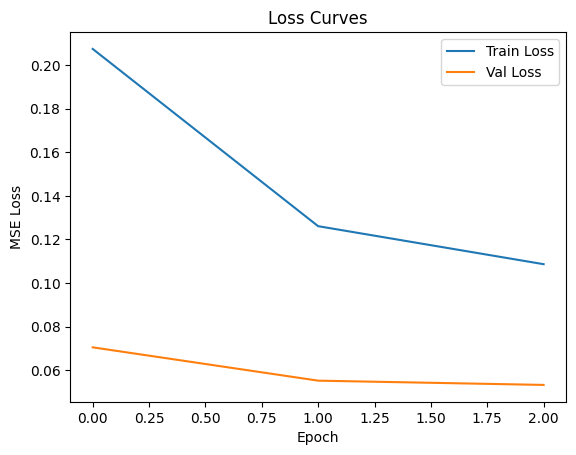

In [20]:
import matplotlib.pyplot as plt

# Plot losses in order to make sure the model isn't overfitting.
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title('Loss Curves')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()

In [21]:
# Show current ESM-based predictions.
df_pred[['mutant', 'DMS_score_predicted']].head(n=10)

,mutant,DMS_score_predicted
0,V1D,0.116978
1,V1Y,0.117166
2,V1C,0.116745
3,V1A,0.116582
4,V1E,0.117279
5,V1W,0.117084
6,V1T,0.117078
7,V1R,0.117258
8,V1Q,0.117028
9,V1S,0.116942


In [22]:
# Save predictions to .csv.
df_pred[['mutant', 'DMS_score_predicted']].to_csv('test_predictions.csv', index=False)

In [23]:
group_number = "1"

with open("GroupName.txt", "w") as f:
    f.write(group_number.strip() + "\n")

print("Saved GroupName.txt")

Saved GroupName.txt


In [24]:
api_key = "df303a548bec1afcff7d7196650c5396cfa74c94a8be5357043602dcc7537ba7"

with open("APIKey.txt", "w") as f:
    f.write(api_key.strip() + "\n")

print("Saved APIKey.txt")

Saved APIKey.txt


## 3. Select Query for Next Round

In [25]:
# Show prediction distribution.
df_pred.sort_values('DMS_score_predicted', ascending=False)

,mutant,sequence,DMS_score_predicted
3391,K198A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.118026
4430,V268E,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.117922
3396,K198S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.117885
4449,K269S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.117884
4469,L270D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.117876
...,...,...,...
5255,L332D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.113777
3680,L213E,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.113561
9924,W582D,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.113242
8636,F514E,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.113197


In [26]:
# Write mutants with top ten DMS scores to .txt file.
df_top_ten = df_pred.sort_values('DMS_score_predicted', ascending=False).head(n=10)
df_top_ten.to_csv('top10.txt', columns=['mutant'], index=False, header=False)
print(df_top_ten)

      mutant                                           sequence  \
3391   K198A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
4430   V268E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
3396   K198S  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
4449   K269S  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
4469   L270D  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
4470   L270E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
1051    K57P  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10840  C630P  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
2795   I160E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
4508   K272E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   

       DMS_score_predicted  
3391              0.118026  
4430              0.117922  
3396              0.117885  
4449              0.117884  
4469              0.117876  
4470              0.117846  
1051              0.117843  
10840             0.117831  
2

In [27]:
# Example: randomly select 100 test variants to be queried.
# Note: Random selection may not be a good strategy
# TODO: Select query mutants for the next round based on your own criteria

queries = np.random.choice(df_test.mutant.values, size=100, replace=False)
queries

array(['L273A', 'V574M', 'G120C', 'E601L', 'A194R', 'I364P', 'M109T',
       'K179Y', 'D209S', 'S28D', 'P354R', 'G595V', 'V497S', 'I76E',
       'S372E', 'A460L', 'H262A', 'E653H', 'N323G', 'F365Q', 'K467D',
       'T516A', 'P626G', 'K145N', 'G161H', 'K179V', 'F405L', 'I562Q',
       'G21P', 'P65R', 'V473P', 'P285C', 'V621Q', 'K287V', 'R51W',
       'A219G', 'T638N', 'L452M', 'P12R', 'G16N', 'P159F', 'I137E',
       'F405D', 'H41K', 'F206P', 'N648H', 'A523P', 'N474T', 'V239A',
       'E519T', 'T68V', 'N445L', 'I568N', 'R593V', 'D209T', 'P603Y',
       'S493E', 'E545P', 'N643P', 'I487Q', 'S429A', 'P485C', 'F587A',
       'V92G', 'L313Y', 'S24D', 'N474I', 'A154P', 'V449G', 'E3M', 'S391C',
       'G500T', 'E359H', 'A349D', 'L332D', 'P655H', 'G86I', 'N486G',
       'D176V', 'G421W', 'A461K', 'S372V', 'G204K', 'F587S', 'P394G',
       'E359C', 'P197S', 'E39Y', 'F563N', 'S429P', 'L14S', 'H200R', 'S9K',
       'R45M', 'L10E', 'P197R', 'T114C', 'P655I', 'I181V', 'M153E'],
      dtype=object)

In [28]:
with open('query.txt', 'w') as f:
  for mutant in queries:
    f.write(mutant+'\n')